In [1]:
import numpy as np

from reader import *
from encoder import *

bunny_model = Reader.read_from_file('assets/bunny.obj')

baseline_encoder = BaselineEncoder()
baseline_compressed_model = baseline_encoder.encode(bunny_model)

import matplotlib.pyplot as plt


def print_statistics(compressed_model, name):
    print(f"{name} statistics:")
    print(f"- Bytes per triangle: {compressed_model.bits_per_triangle / 8:.2f}")
    print(f"- Bytes per vertex: {compressed_model.bits_per_vertex / 8:.2f}")
    print(f"- Compression rate: {baseline_compressed_model.bits_per_vertex / compressed_model.bits_per_vertex:.2f}")


print_statistics(baseline_compressed_model, "BaselineEncoder")

BaselineEncoder statistics:
- Bytes per triangle: 18.00
- Bytes per vertex: 36.00
- Compression rate: 1.00


In [7]:
import pyvista as pv
import numpy as np

# -----------------------------------------------------------------------------
# STEP 1: Load (or create) a mesh
# -----------------------------------------------------------------------------
# Replace this with pv.read("your_mesh_file.obj") or .stl/.ply/.vtp/etc.
# mesh = pv.Sphere(radius=1.0, theta_resolution=60, phi_resolution=60)
mesh = pv.read('assets/bunny.obj')

# -----------------------------------------------------------------------------
# STEP 2: Set up the Plotter
# -----------------------------------------------------------------------------
plotter = pv.Plotter()

# Add initial mesh actor (with faces visible)
actor = plotter.add_mesh(
    mesh,
    opacity=1.0,
    show_edges=False,
    color="lightsteelblue",
)

# Also add a "point cloud" actor for the same vertices—but hide it by default.
points_actor = plotter.add_points(
    mesh.points,
    color="tomato",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)
# points_actor.SetVisibility(False)
#
# # -----------------------------------------------------------------------------
# # STEP 3: Define callback functions for each slider
# # -----------------------------------------------------------------------------
# def update_opacity(value):
#     """Slider callback to change mesh (or point) opacity."""
#     actor.GetProperty().SetOpacity(value)
#     points_actor.GetProperty().SetOpacity(value)
#     plotter.render()
#
#
# def update_point_size(value):
#     """Slider callback to change point size when in 'vertices only' mode."""
#     points_actor.GetProperty().SetPointSize(int(value))
#     plotter.render()
#
#
# def toggle_vertices_only(value):
#     """
#     Slider callback to switch between full‐mesh (0) and vertices‐only (1).
#     If value < 0.5, treat as 0; else treat as 1.
#     """
#     mode = int(round(value))
#     if mode == 0:
#         # Show faces, hide points
#         actor.SetVisibility(True)
#         points_actor.SetVisibility(False)
#     else:
#         # Show only points, hide faces
#         actor.SetVisibility(False)
#         points_actor.SetVisibility(True)
#     plotter.render()
#
#
# # -----------------------------------------------------------------------------
# # STEP 4: Add sliders to the Plotter UI
# # -----------------------------------------------------------------------------
# # 1) Opacity slider: range [0.0, 1.0]
# plotter.add_slider_widget(
#     callback=update_opacity,
#     rng=[0.0, 1.0],
#     value=1.0,
#     title="Opacity",
#     pointa=(0.025, 0.1),
#     pointb=(0.31, 0.1),
#     style="modern",
# )
#
# # 2) Point size slider: range [1, 10]
# plotter.add_slider_widget(
#     callback=update_point_size,
#     rng=[1, 10],
#     value=5,
#     title="Point Size",
#     pointa=(0.025, 0.025),
#     pointb=(0.31, 0.025),
#     style="modern",
# )
#
# # 3) “Vertices only” toggle slider: range [0, 1]
# plotter.add_slider_widget(
#     callback=toggle_vertices_only,
#     rng=[0, 1],
#     value=0,
#     title="Vertices Only (0/1)",
#     pointa=(0.4, 0.025),
#     pointb=(0.685, 0.025),
#     style="modern",
#     fmt="%.0f",  # display as integer
# )

# -----------------------------------------------------------------------------
# STEP 5: Display the interactive window
# -----------------------------------------------------------------------------
plotter.add_text("Drag sliders to update view", position="upper_left", font_size=10)
plotter.show(title="Interactive 3D Mesh Viewer", window_size=[800, 600])


Widget(value='<iframe src="http://localhost:59175/index.html?ui=P_0x26722217590_4&reconnect=auto" class="pyvis…

In [3]:
# from pyvista import examples
# mesh = examples.download_dragon()
# mesh['scalars'] = mesh.points[:, 1]
# mesh.plot(cpos='xy', cmap='plasma')

In [2]:
len(bunny_model.vertices)

3840

In [4]:
for vertex_idx in range(len(bunny_model.vertices)):
    found = False
    for triangle in bunny_model.triangles:
        if triangle.a == vertex_idx or triangle.b == vertex_idx or triangle.c == vertex_idx:
            found = True
            break
    if not found:
        print(f"Vertex {vertex_idx} is not used in any triangle")

In [5]:
min_vertex_id = 100
max_vertex_id = -1

for triangle in bunny_model.triangles:
    min_vertex_id = min(min_vertex_id, triangle.a, triangle.b, triangle.c)
    max_vertex_id = max(max_vertex_id, triangle.a, triangle.b, triangle.c)
min_vertex_id, max_vertex_id

(0, 3839)

In [6]:
bunny_model.triangles

[Triangle(a=0, b=48, c=49),
 Triangle(a=49, b=50, c=2),
 Triangle(a=50, b=51, c=3),
 Triangle(a=51, b=52, c=4),
 Triangle(a=52, b=53, c=5),
 Triangle(a=53, b=54, c=6),
 Triangle(a=54, b=55, c=7),
 Triangle(a=55, b=56, c=8),
 Triangle(a=56, b=57, c=9),
 Triangle(a=57, b=58, c=10),
 Triangle(a=58, b=59, c=11),
 Triangle(a=59, b=60, c=12),
 Triangle(a=60, b=61, c=13),
 Triangle(a=61, b=62, c=14),
 Triangle(a=62, b=63, c=15),
 Triangle(a=15, b=63, c=64),
 Triangle(a=64, b=65, c=17),
 Triangle(a=65, b=66, c=18),
 Triangle(a=18, b=66, c=67),
 Triangle(a=67, b=68, c=20),
 Triangle(a=68, b=69, c=21),
 Triangle(a=69, b=70, c=22),
 Triangle(a=70, b=71, c=23),
 Triangle(a=23, b=71, c=72),
 Triangle(a=72, b=73, c=25),
 Triangle(a=25, b=73, c=74),
 Triangle(a=26, b=74, c=75),
 Triangle(a=27, b=75, c=76),
 Triangle(a=28, b=76, c=77),
 Triangle(a=77, b=78, c=30),
 Triangle(a=30, b=78, c=79),
 Triangle(a=31, b=79, c=80),
 Triangle(a=80, b=81, c=33),
 Triangle(a=81, b=82, c=34),
 Triangle(a=34, b=82, c

In [7]:
gts_parallelogram_predictor_huffman_encoder = GTSParallelogramPredictor(pack_strip=Packing.RADIX_BINARY_TREE,
                                                                        entropy_encoder_type=Packing.HUFFMAN_ENCODER,
                                                                        enable_entropy_encoder_conditional_probabilities=False,
                                                                        verbose=True)
gts_parallelogram_predictor_huffman_encoder_compressed_model = gts_parallelogram_predictor_huffman_encoder.encode(
    bunny_model)

print_statistics(gts_parallelogram_predictor_huffman_encoder_compressed_model,
                 "GTSParallelogramPredictor(Huffman encoder)")

GTSQuantizator verbose statistics:
- Header (in bytes): 32
- Triangles strip entropy: 13.589
- Triangles strip average code bit length: 9.194
- Triangles strip (in bytes): 11113


ValueError: operands could not be broadcast together with shapes (256,) (2048,) 

In [7]:
gts_parallelogram_predictor_adaptive_huffman_encoder = GTSParallelogramPredictor(
    pack_strip=Packing.RADIX_BINARY_TREE,
    entropy_encoder_type=Packing.HUFFMAN_ENCODER,
    enable_entropy_encoder_conditional_probabilities=True,
    verbose=True)
gts_parallelogram_predictor_adaptive_huffman_encoder_compressed_model = gts_parallelogram_predictor_adaptive_huffman_encoder.encode(
    bunny_model)

print_statistics(gts_parallelogram_predictor_adaptive_huffman_encoder_compressed_model,
                 "GTSParallelogramPredictor(adaptive Huffman encoder)")

IndexError: list index out of range

In [8]:
gts_parallelogram_predictor_arithmetic_encoder = GTSParallelogramPredictor(pack_strip=Packing.RADIX_BINARY_TREE,
                                                                           entropy_encoder_type=Packing.ARITHMETIC_ENCODER,
                                                                           enable_entropy_encoder_conditional_probabilities=False,
                                                                           verbose=True)
gts_parallelogram_predictor_arithmetic_encoder_compressed_model = gts_parallelogram_predictor_arithmetic_encoder.encode(
    bunny_model)

print_statistics(gts_parallelogram_predictor_arithmetic_encoder_compressed_model,
                 "GTSParallelogramPredictor(arithmetic encoder)")

IndexError: list index out of range

In [9]:
gts_parallelogram_predictor_adaptive_arithmetic_encoder = GTSParallelogramPredictor(
    pack_strip=Packing.RADIX_BINARY_TREE,
    entropy_encoder_type=Packing.ARITHMETIC_ENCODER,
    enable_entropy_encoder_conditional_probabilities=True,
    verbose=True)
gts_parallelogram_predictor_adaptive_arithmetic_encoder_compressed_model = gts_parallelogram_predictor_adaptive_arithmetic_encoder.encode(
    bunny_model)

print_statistics(gts_parallelogram_predictor_adaptive_arithmetic_encoder_compressed_model,
                 "GTSParallelogramPredictor(adaptive arithmetic encoder)")

IndexError: list index out of range

In [13]:
packed_gts_encoder_radix_binary_tree_packing = PackedGTSQuantizator(pack_strip=Packing.RADIX_BINARY_TREE,
                                                                    verbose=True)
packed_gts_encoder_radix_binary_tree_packing_compressed_model = packed_gts_encoder_radix_binary_tree_packing.encode(
    bunny_model)

print_statistics(packed_gts_encoder_radix_binary_tree_packing_compressed_model,
                 "PackedGTSQuantizator(radix binary tree packing)")

IndexError: list index out of range

In [14]:
encoder_no_packing = SimpleQuantizator(pack_strip=Packing.NONE, verbose=True)
encoder_no_packing_compressed_model = encoder_no_packing.encode(bunny_model)

print_statistics(encoder_no_packing_compressed_model, "SimpleQuantizator(no packing)")

SimpleQuantizator verbose statistics:
- Header (in bytes): 32
- Triangles strip entropy: 11.768
- Triangles strip average code bit length: 32.000
- Triangles strip (in bytes): 63960
- Quantized vertices entropy: 8.83766492843303
- Quantized vertices average code bit length: 12.000
- Quantized vertices (in bytes): 17280
SimpleQuantizator(no packing) statistics:
- Bytes per triangle: 10.58
- Bytes per vertex: 21.16
- Compression rate: 1.70


In [15]:
encoder_fixed_packing = SimpleQuantizator(pack_strip=Packing.FIXED, verbose=True)
encoder_fixed_packing_model = encoder_fixed_packing.encode(bunny_model)

print_statistics(encoder_fixed_packing_model, "SimpleQuantizator(fixed packing)")

SimpleQuantizator verbose statistics:
- Header (in bytes): 32
- Triangles strip entropy: 11.768
- Triangles strip average code bit length: 12.000
- Triangles strip (in bytes): 23985
- Quantized vertices entropy: 8.83766492843303
- Quantized vertices average code bit length: 12.000
- Quantized vertices (in bytes): 17280
SimpleQuantizator(fixed packing) statistics:
- Bytes per triangle: 5.38
- Bytes per vertex: 10.75
- Compression rate: 3.35


In [16]:
encoder_binary_range_partitioning_packing = SimpleQuantizator(pack_strip=Packing.BINARY_RANGE_PARTITIONING,
                                                              verbose=True)
encoder_binary_range_partitioning_packing_compressed_model = encoder_binary_range_partitioning_packing.encode(
    bunny_model)

print_statistics(encoder_binary_range_partitioning_packing_compressed_model,
                 "SimpleQuantizator(binary range partitioning packing)")

SimpleQuantizator verbose statistics:
- Header (in bytes): 32


IndexError: list index out of range

In [10]:
encoder_binary_range_partitioning_packing = SimpleQuantizator(pack_strip=Packing.BINARY_RANGE_PARTITIONING,
                                                              allow_reorder=True, verbose=True)
encoder_binary_range_partitioning_packing_compressed_model = encoder_binary_range_partitioning_packing.encode(
    bunny_model)

print_statistics(encoder_binary_range_partitioning_packing_compressed_model,
                 "SimpleQuantizator(binary range partitioning packing, reordered)")

SimpleQuantizator verbose statistics:
- Header (in bytes): 32
- Triangles strip entropy: 11.145
- Triangles strip average code bit length: 11.465
- Triangles strip (in bytes): 16604
- Quantized vertices entropy: 11.520605177332088
- Quantized vertices average code bit length: 12.002
- Quantized vertices (in bytes): 11265
SimpleQuantizator(binary range partitioning packing, reordered) statistics:
- Bytes per triangle: 5.62
- Bytes per vertex: 11.15
- Compression rate: 3.21


In [11]:
encoder_radix_binary_tree_packing = SimpleQuantizator(pack_strip=Packing.RADIX_BINARY_TREE, verbose=True)
encoder_radix_binary_tree_packing_compressed_model = encoder_radix_binary_tree_packing.encode(bunny_model)

print_statistics(encoder_radix_binary_tree_packing_compressed_model, "SimpleQuantizator(radix binary tree packing)")

SimpleQuantizator verbose statistics:
- Header (in bytes): 32
- Triangles strip entropy: 11.145
- Triangles strip average code bit length: 11.363
- Triangles strip (in bytes): 16456
- Quantized vertices entropy: 11.52060517733206
- Quantized vertices average code bit length: 12.002
- Quantized vertices (in bytes): 11265
SimpleQuantizator(radix binary tree packing) statistics:
- Bytes per triangle: 5.59
- Bytes per vertex: 11.09
- Compression rate: 3.23


In [12]:
encoder_radix_binary_tree_packing = SimpleQuantizator(pack_strip=Packing.RADIX_BINARY_TREE, allow_reorder=True,
                                                      verbose=True)
encoder_radix_binary_tree_packing_compressed_model = encoder_radix_binary_tree_packing.encode(bunny_model)

print_statistics(encoder_radix_binary_tree_packing_compressed_model,
                 "SimpleQuantizator(radix binary tree packing, reordered)")

SimpleQuantizator verbose statistics:
- Header (in bytes): 32
- Triangles strip entropy: 11.145
- Triangles strip average code bit length: 11.208
- Triangles strip (in bytes): 16232
- Quantized vertices entropy: 11.5206051773321
- Quantized vertices average code bit length: 12.002
- Quantized vertices (in bytes): 11265
SimpleQuantizator(radix binary tree packing, reordered) statistics:
- Bytes per triangle: 5.54
- Bytes per vertex: 11.00
- Compression rate: 3.26


In [13]:
gts_encoder_fixed_packing = GTSQuantizator(pack_strip=Packing.FIXED, verbose=True)
gts_encoder_fixed_packing_compressed_model = gts_encoder_fixed_packing.encode(bunny_model)

print_statistics(gts_encoder_fixed_packing_compressed_model, "GTSQuantizator(fixed packing)")

GTSQuantizator verbose statistics:
- Header (in bytes): 32
- Triangles strip entropy: 12.132
- Triangles strip average code bit length: 13.000
- Triangles strip (in bytes): 12665
- Quantized vertices entropy: 11.52060517733206
- Quantized vertices average code bit length: 12.002
- Quantized vertices (in bytes): 11265
GTSQuantizator(fixed packing) statistics:
- Bytes per triangle: 4.82
- Bytes per vertex: 9.57
- Compression rate: 3.74


In [14]:
gts_encoder_radix_binary_tree_packing = GTSQuantizator(pack_strip=Packing.RADIX_BINARY_TREE, verbose=True)
gts_encoder_radix_binary_tree_packing_compressed_model = gts_encoder_radix_binary_tree_packing.encode(bunny_model)

print_statistics(gts_encoder_radix_binary_tree_packing_compressed_model, "GTSQuantizator(radix binary tree packing)")

GTSQuantizator verbose statistics:
- Header (in bytes): 32
- Triangles strip entropy: 12.132
- Triangles strip average code bit length: 12.355
- Triangles strip (in bytes): 12037
- Quantized vertices entropy: 11.52060517733206
- Quantized vertices average code bit length: 12.002
- Quantized vertices (in bytes): 11265
GTSQuantizator(radix binary tree packing) statistics:
- Bytes per triangle: 4.70
- Bytes per vertex: 9.32
- Compression rate: 3.84


In [15]:
packed_gts_encoder_fixed_packing = PackedGTSQuantizator(pack_strip=Packing.FIXED, verbose=True)
packed_gts_encoder_fixed_packing_compressed_model = packed_gts_encoder_fixed_packing.encode(bunny_model)

print_statistics(packed_gts_encoder_fixed_packing_compressed_model, "PackedGTSQuantizator(fixed packing)")

GTSQuantizator verbose statistics:
- Header (in bytes): 32
- Triangles strip entropy: 12.822
- Triangles strip average code bit length: 10.146
- Triangles strip (in bytes): 9885
- Quantized vertices entropy: 11.520605177332085
- Quantized vertices average code bit length: 12.002
- Quantized vertices (in bytes): 11265
PackedGTSQuantizator(fixed packing) statistics:
- Bytes per triangle: 4.26
- Bytes per vertex: 8.46
- Compression rate: 4.23


In [16]:
packed_gts_encoder_radix_binary_tree_packing = PackedGTSQuantizator(pack_strip=Packing.RADIX_BINARY_TREE,
                                                                    verbose=True)
packed_gts_encoder_radix_binary_tree_packing_compressed_model = packed_gts_encoder_radix_binary_tree_packing.encode(
    bunny_model)

print_statistics(packed_gts_encoder_radix_binary_tree_packing_compressed_model,
                 "PackedGTSQuantizator(radix binary tree packing)")

GTSQuantizator verbose statistics:
- Header (in bytes): 32
- Triangles strip entropy: 12.822
- Triangles strip average code bit length: 9.708
- Triangles strip (in bytes): 9458
- Quantized vertices entropy: 11.520605177332085
- Quantized vertices average code bit length: 12.002
- Quantized vertices (in bytes): 11265
PackedGTSQuantizator(radix binary tree packing) statistics:
- Bytes per triangle: 4.18
- Bytes per vertex: 8.29
- Compression rate: 4.32


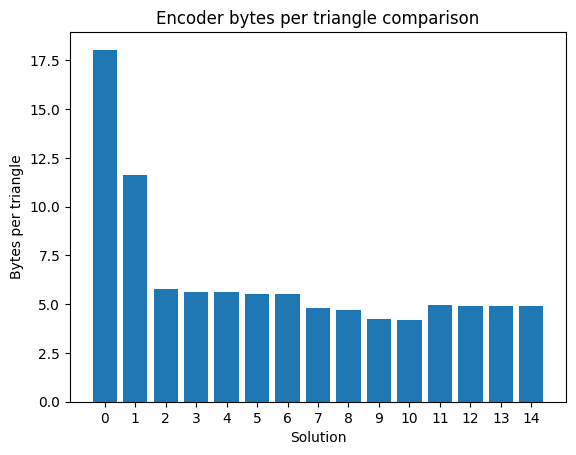

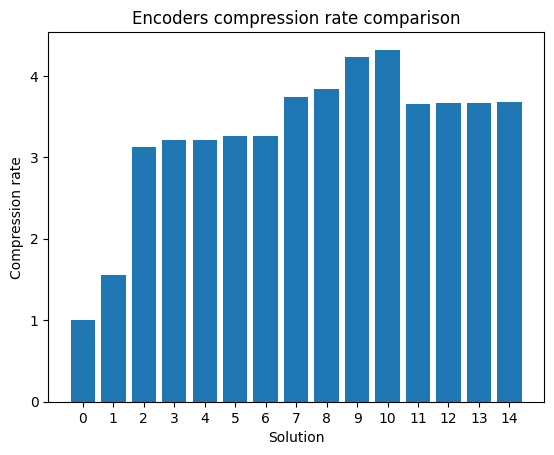

In [19]:

def show_and_save_bar_plots(compressed_models: List[CompressedModel]):
    bytes_per_triangle = [model.bits_per_triangle / 8 for model in compressed_models]
    compression_rate = [baseline_compressed_model.bits_per_vertex / model.bits_per_vertex for model in
                        compressed_models]

    # Create the histogram
    plt.bar(list(range(len(bytes_per_triangle))), bytes_per_triangle)

    # Add title and labels
    plt.title('Encoder bytes per triangle comparison')
    plt.xlabel('Solution')
    plt.xticks(list(range(len(bytes_per_triangle))))
    plt.ylabel('Bytes per triangle')

    # Save the histogram as an image
    plt.savefig('images/bytes_per_triangle_bar_plot.png')  # Save as PNG file
    plt.show()  # Display the plot

    # Create the histogram
    plt.bar(list(range(len(compression_rate))), compression_rate)

    # Add title and labels
    plt.title('Encoders compression rate comparison')
    plt.xlabel('Solution')
    plt.xticks(list(range(len(compression_rate))))
    plt.ylabel('Compression rate')

    # Save the histogram as an image
    plt.savefig('images/compression_rate_bar_plot.png')  # Save as PNG file
    plt.show()  # Display the plot


show_and_save_bar_plots([baseline_compressed_model, encoder_no_packing_compressed_model, encoder_fixed_packing_model,
                         encoder_binary_range_partitioning_packing_compressed_model,
                         encoder_binary_range_partitioning_packing_compressed_model,
                         encoder_radix_binary_tree_packing_compressed_model,
                         encoder_radix_binary_tree_packing_compressed_model, gts_encoder_fixed_packing_compressed_model,
                         gts_encoder_radix_binary_tree_packing_compressed_model,
                         packed_gts_encoder_fixed_packing_compressed_model,
                         packed_gts_encoder_radix_binary_tree_packing_compressed_model,
                         gts_parallelogram_predictor_huffman_encoder_compressed_model,
                         gts_parallelogram_predictor_adaptive_huffman_encoder_compressed_model,
                         gts_parallelogram_predictor_arithmetic_encoder_compressed_model,
                         gts_parallelogram_predictor_adaptive_arithmetic_encoder_compressed_model,
                         ])

In [552]:
from typing import List, Tuple, Set

class HalfEdgeFace:
    id_counter = 0

    def __init__(self, x, y, z):
        self.x = x
        self.y = y
        self.z = z
        self.id = HalfEdgeFace.id_counter
        HalfEdgeFace.id_counter += 1
        # self.half_edge = None  # One of the half-edges bounding this face

class HalfEdge:
    id_counter = 0

    def __init__(self):
        self.id = HalfEdge.id_counter
        HalfEdge.id_counter += 1
        self.s = None  # Starting vertex
        self.e = None  # Ending vertex
        self.v = None  # Third vertex in the triangle
        self.n = None  # Next half-edge in the triangle
        self.p = None  # Previous half-edge in the triangle
        self.o = None  # Opposite half-edge
        self.N = None  # Next half-edge in the boundary containing this edge
        self.P = None  # Previous half-edge in the boundary containing this edge
        self.f = None  # Face to which this half-edge correspond
        self.m = False  # Is vertex marked (visited)
        self._is_boundary = False
        self.face: HalfEdgeFace = None

    def is_boundary(self):
        return self._is_boundary

    def set_is_boundary(self, is_boundary: bool):
        self._is_boundary = is_boundary

    def __repr__(self):
        return f"HalfEdge(id={self.id}, s={self.s.id}, e={self.e.id}, v={self.v.id if self.v is not None else None}, o={self.o.id if self.o is not None else None}, f={self.f.id if self.f is not None else None}, n={self.n.id if self.n is not None else None}, p={self.p.id if self.p is not None else None}, N={self.N.id if self.N is not None else None}, P={self.P.id if self.P is not None else None})"


class HalfEdgeVertex:
    id_counter = 0

    def __init__(self, vertex: Vertex):
        self.vertex: Vertex = vertex
        self.id: int = HalfEdgeVertex.id_counter
        HalfEdgeVertex.id_counter += 1
        # self.half_edge = None  # One of the half-edges starting at this vertex
        self.m = False  # Is vertex marked (visited)
        self.ingoing_half_edges: Set[HalfEdge] = set()
        self.outgoing_half_edges: Set[HalfEdge] = set()
        self.face: HalfEdgeFace = None

    def add_ingoing_half_edge(self, half_edge: HalfEdge):
        self.ingoing_half_edges.add(half_edge)

    def add_outgoing_half_edge(self, half_edge: HalfEdge):
        self.outgoing_half_edges.add(half_edge)

    def get_all_ingoing_half_edges(self) -> Set[HalfEdge]:
        return self.ingoing_half_edges

    def get_all_outgoing_half_edges(self) -> Set[HalfEdge]:
        return self.outgoing_half_edges

    def __repr__(self):
        return f"HalfEdgeVertex(id={self.id}, v={self.vertex}, in_half_edge_count={len(self.ingoing_half_edges)}, out_half_edge_count={len(self.outgoing_half_edges)}, m={self.m})"




class HalfEdgeMesh:
    def __init__(self, model: Model = None):
        HalfEdgeFace.id_counter = 0
        HalfEdge.id_counter = 0
        HalfEdgeVertex.id_counter = 0

        self.model = model
        self.half_edges: List[HalfEdge] = []  # List of half-edges
        self.faces: List[HalfEdgeFace] = []  # List of faces
        self.edge_map: dict[tuple[int, int], HalfEdge] = dict()
        self.vertex_map: dict[int, HalfEdgeVertex] = dict()

        self._build_half_edge_mesh()

    def _build_half_edge_mesh(self):
        self._init_vertex_map()

        # Create half-edges and faces
        for triangle in self.model.triangles:
            v0, v1, v2 = triangle.a, triangle.b, triangle.c
            hev0, hev1, hev2 = self.vertex_map[v0], self.vertex_map[v1], self.vertex_map[v2]

            face = HalfEdgeFace(hev0, hev1, hev2)
            self.faces.append(face)

            hev0.face = hev1.face = hev2.face = face

            he0, he1, he2 = HalfEdge(), HalfEdge(), HalfEdge()
            he0.face = he1.face = he2.face = face

            he0.s, he1.s, he2.s = hev0, hev1, hev2
            he0.e, he1.e, he2.e = hev1, hev2, hev0
            he0.v, he1.v, he2.v = hev2, hev0, hev1

            he0.n, he1.n, he2.n = he1, he2, he0
            he0.p, he1.p, he2.p = he2, he0, he1

            hev0.add_outgoing_half_edge(he0)
            hev1.add_ingoing_half_edge(he0)
            hev1.add_outgoing_half_edge(he1)
            hev2.add_ingoing_half_edge(he1)
            hev2.add_outgoing_half_edge(he2)
            hev0.add_ingoing_half_edge(he2)

            self._add_edge(he0, (he0.s.id, he0.e.id))
            self._add_edge(he1, (he1.s.id, he1.e.id))
            self._add_edge(he2, (he2.s.id, he2.e.id))

            self.half_edges.extend([he0, he1, he2])

            he0.f = he1.f = he2.f = face

        self._create_boundary_half_edges()

    def _init_vertex_map(self):
        # Create vertices and store them in a dictionary
        for i, v in enumerate(self.model.vertices):
            self.vertex_map[i] = HalfEdgeVertex(v)

    def _add_edge(self, half_edge: HalfEdge, edge: Tuple[int, int]):
        if edge not in self.edge_map:
            self.edge_map[edge] = half_edge

        if (edge[1], edge[0]) in self.edge_map:
            opposite = self.edge_map[(edge[1], edge[0])]
            half_edge.o = opposite
            opposite.o = half_edge

    def get_copy(self):
        he_mesh_copy = HalfEdgeMesh(self.model)
        return he_mesh_copy

    def _create_boundary_half_edges(self):
        for half_edge in self.half_edges:
            if half_edge.o is None:
                half_edge.set_is_boundary(True)
            else:
                half_edge.set_is_boundary(False)


In [553]:
test_model = Model(
    [Vertex(0, 0, 0), Vertex(3, 0, 0), Vertex(2, 3, 0), Vertex(5, 3, 0), Vertex(6, 6, 0), Vertex(4, 6, 0)],
    [Triangle(0, 1, 2), Triangle(2, 1, 3), Triangle(3, 4, 5)])

In [604]:
test_model3 = Model(
    [Vertex(-1, 0, 0), Vertex(0, 0, 0), Vertex(3, 0, 0), Vertex(1.5, 3, 0), Vertex(4.5, 3, 0), Vertex(6, 6, 0), Vertex(3, 6, 0), Vertex(4.5, 4, 0)],
    [Triangle(1, 2, 3), Triangle(3, 2, 4), Triangle(7, 5, 6)])

In [605]:
test_half_edge_mesh = HalfEdgeMesh(test_model3)

In [606]:
test_half_edge_mesh.edge_map

{(1, 2): HalfEdge(id=0, s=1, e=2, v=3, o=None, f=0, n=1, p=2, N=None, P=None),
 (2, 3): HalfEdge(id=1, s=2, e=3, v=1, o=3, f=0, n=2, p=0, N=None, P=None),
 (3, 1): HalfEdge(id=2, s=3, e=1, v=2, o=None, f=0, n=0, p=1, N=None, P=None),
 (3, 2): HalfEdge(id=3, s=3, e=2, v=4, o=1, f=1, n=4, p=5, N=None, P=None),
 (2, 4): HalfEdge(id=4, s=2, e=4, v=3, o=None, f=1, n=5, p=3, N=None, P=None),
 (4, 3): HalfEdge(id=5, s=4, e=3, v=2, o=None, f=1, n=3, p=4, N=None, P=None),
 (7, 5): HalfEdge(id=6, s=7, e=5, v=6, o=None, f=2, n=7, p=8, N=None, P=None),
 (5, 6): HalfEdge(id=7, s=5, e=6, v=7, o=None, f=2, n=8, p=6, N=None, P=None),
 (6, 7): HalfEdge(id=8, s=6, e=7, v=5, o=None, f=2, n=6, p=7, N=None, P=None)}

In [607]:
test_half_edge_mesh.vertex_map

{0: HalfEdgeVertex(id=0, v=Vertex(x=-1, y=0, z=0), in_half_edge_count=0, out_half_edge_count=0, m=False),
 1: HalfEdgeVertex(id=1, v=Vertex(x=0, y=0, z=0), in_half_edge_count=1, out_half_edge_count=1, m=False),
 2: HalfEdgeVertex(id=2, v=Vertex(x=3, y=0, z=0), in_half_edge_count=2, out_half_edge_count=2, m=False),
 3: HalfEdgeVertex(id=3, v=Vertex(x=1.5, y=3, z=0), in_half_edge_count=2, out_half_edge_count=2, m=False),
 4: HalfEdgeVertex(id=4, v=Vertex(x=4.5, y=3, z=0), in_half_edge_count=1, out_half_edge_count=1, m=False),
 5: HalfEdgeVertex(id=5, v=Vertex(x=6, y=6, z=0), in_half_edge_count=1, out_half_edge_count=1, m=False),
 6: HalfEdgeVertex(id=6, v=Vertex(x=3, y=6, z=0), in_half_edge_count=1, out_half_edge_count=1, m=False),
 7: HalfEdgeVertex(id=7, v=Vertex(x=4.5, y=4, z=0), in_half_edge_count=1, out_half_edge_count=1, m=False)}

In [608]:
test_half_edge_mesh.half_edges

[HalfEdge(id=0, s=1, e=2, v=3, o=None, f=0, n=1, p=2, N=None, P=None),
 HalfEdge(id=1, s=2, e=3, v=1, o=3, f=0, n=2, p=0, N=None, P=None),
 HalfEdge(id=2, s=3, e=1, v=2, o=None, f=0, n=0, p=1, N=None, P=None),
 HalfEdge(id=3, s=3, e=2, v=4, o=1, f=1, n=4, p=5, N=None, P=None),
 HalfEdge(id=4, s=2, e=4, v=3, o=None, f=1, n=5, p=3, N=None, P=None),
 HalfEdge(id=5, s=4, e=3, v=2, o=None, f=1, n=3, p=4, N=None, P=None),
 HalfEdge(id=6, s=7, e=5, v=6, o=None, f=2, n=7, p=8, N=None, P=None),
 HalfEdge(id=7, s=5, e=6, v=7, o=None, f=2, n=8, p=6, N=None, P=None),
 HalfEdge(id=8, s=6, e=7, v=5, o=None, f=2, n=6, p=7, N=None, P=None)]

In [609]:
from enum import IntEnum
from copy import deepcopy
from typing import List
from tqdm import tqdm


class EdgeBreakerEncoder(Encoder):
    class CLERS(IntEnum):
        C = 0
        L = 1
        E = 2
        R = 3
        S = 4

    def __init__(self, verbose=False):
        # Verbosity flag for debugging/tracking operations
        self.verbose = verbose
        self.half_edge_mesh = None
        self.P: List[HalfEdgeVertex] = []  # list of points (vertices)
        self.H: List[EdgeBreakerEncoder.CLERS] = []  # history (list of op-codes/CLERS)
        self.B: List[HalfEdge] = []  # list of boundary half-edges
        self.gate_stack: List[HalfEdge] = []  # stack of gates of all regions

    def encode(self, model: Model) -> CompressedModel:
        """
        Compress the given 3D model mesh using the Edgebreaker algorithm.
        :param model: A triangulated 3D model.
        :return: A compressed representation of the model.
        """

        self.half_edge_mesh = HalfEdgeMesh(model)

        self._initialize()

        # self._compress()
        # gate = self._get_next_gate()

        return CompressedModel(bytes(), 0., 0.)

    def _initialize(self):
        self.B = [he for he in self.half_edge_mesh.half_edges if he.is_boundary()]



        # print(f"_initialize")
        # self.gate_stack.append(None)
        # self.B = [he for he in self.half_edge_mesh.half_edges if he.o is None]
        # B_ids = {he.id for he in self.B}

        def get_next_gate():
            for he in self.B:
                if not he.m and he.is_boundary():
                    return he
            return None

        def get_next_boundary_half_edge(he: HalfEdge, gate: HalfEdge):
            for next_he in he.e.get_all_outgoing_half_edges():
                if next_he.is_boundary() and (next_he.m == False or next_he == gate):
                    return next_he
            return None

            # for heo in self.B:
            #     if heo.o is None and (heo.m == False or heo == gate) and he.e == heo.s:
            #         return heo
            # return None

        gate = get_next_gate()

        while gate is not None:
            print(f"gate: {gate.id}")
            self.gate_stack.append(gate)

            next_he = gate
            while True:
                # print(f"next_he: {next_he.id}")
                next_he.m = True
                next_he.N = get_next_boundary_half_edge(next_he, gate)
                next_he.N.P = next_he
                next_he.s.m = next_he.e.m = True
                self.P.append(next_he.e)
                next_he = next_he.N
                if next_he == gate:
                    break

            gate = get_next_gate()

        self.gate_stack.reverse()
        self.gate_stack.insert(0, None)
        # self.gate_stack = [None] + self.gate_stack.reversed()
        # for v in self.half_edge_mesh.vertex_map.values():
        #     v.m = False

        # for he in self.half_edge_mesh.half_edges:
        #
        #     if he.N is None and he.n.o is None:
        #         he.N = he.n
        #     if he.P is None and he.p.o is None:
        #         he.P = he.p

    # def _compress(self):
    #     total_gate_stack = [v for v in self.gate_stack]
    #     self.original_half_edge_mesh = self.half_edge_mesh.get_copy()
    #     self.total_H = []
    #     self.total_P = []
    #
    #     for v in tqdm(total_gate_stack[1:]):
    #         self.H = []
    #         self.P = []
    #         self.half_edge_mesh = self.original_half_edge_mesh.get_copy()
    #         self._initialize()
    #         self.gate_stack = [None, self.half_edge_mesh.half_edges[v.id]]
    #
    #         print(f"{v = }")
    #         print(f"{self.half_edge_mesh.half_edges[v.id] = }")
    #
    #         self._compress_region()
    #         self.total_H.append(self.H.copy())
    #         self.total_P.append(self.P.copy())

    # def _compress_region(self):
    def _compress(self):
        print(f"_compress")
        # self.gate_stack = [None, self.gate_stack[3]]
        print(self.gate_stack)
        gate = self.gate_stack.pop()

        while gate is not None:
            print(f"gate: {gate.id}")
            # break
            if not gate.v.m:  # case CLERS.C
                print("case CLERS.C")
                self.H.append(self.CLERS.C)  # append C to history
                self.P.append(gate.v)  # append v to P
                # update flags
                gate.m = False
                gate.p.o.m = True
                gate.n.o.m = True
                gate.v.m = True
                # fix red link 1 in B
                gate.p.o.P = gate.P
                gate.P.N = gate.p.o
                # fix red link 2 in B
                gate.p.o.N = gate.n.o
                gate.n.o.P = gate.p.o
                # fix red link 3 in B
                gate.n.o.N = gate.N
                gate.N.P = gate.n.o
                gate = gate.n.o

            elif gate.p == gate.P:  # left edge of X (gate's face) is in B
                if gate.n == gate.N:  # case CLERS.E
                    print("case CLERS.E")
                    self.H.append(self.CLERS.E)  # append E to the history
                    gate.m, gate.n.m, gate.p.m = False, False, False  # unmark edges
                    gate = self.gate_stack.pop()  # pop stack: next region

                else:  # case CLERS.L
                    print("case CLERS.L")
                    self.H.append(self.CLERS.L)  # append L to the history
                    # update marks
                    gate.m = False
                    gate.P.m = False
                    gate.n.o.m = True
                    # fix red link 1 in B
                    gate.P.P.N = gate.n.o
                    gate.n.o.P = gate.P.P
                    # fix red link 2 in B
                    gate.n.o.N = gate.N
                    gate.N.P = gate.n.o

                    gate = gate.n.o  # move gate
            elif gate.n == gate.N:  # case CLERS.R
                print("case CLERS.R")
                self.H.append(self.CLERS.R)  # append R to the history
                # update marks
                gate.m = False
                gate.N.m = False
                gate.p.o.m = True
                # fix red link 1 in B
                gate.N.N.P = gate.p.o
                gate.p.o.N = gate.N.N
                # fix red link 2 in B
                gate.p.o.P = gate.P
                gate.P.N = gate.p.o
                gate = gate.p.o  # move g
            else:  # case CLERS.S
                print("case CLERS.S")
                self.H.append(self.CLERS.S)  # append S to history
                # update marks
                gate.m = False
                gate.p.o.m = True
                gate.n.o.m = True
                b = gate.n  # initial candidate for b
                while not b.m:
                    b = b.o.p  # turn around v to marked b

                # fix red link 1 in B
                gate.P.N = gate.p.o
                gate.p.o.P = gate.P
                # fix red link 2 in B
                gate.p.o.N = b.N
                b.N.P = gate.p.o
                # fix red link 3 in B
                b.N = gate.n.o
                gate.n.o.P = b
                # fix red link 4 in B
                gate.n.o.N = gate.N
                gate.N.P = gate.n.o
                self.gate_stack.append(gate.p.o)  # push gate.p.o on stack
                gate = gate.n.o  # move g


In [612]:
edge_breaker_encoder = EdgeBreakerEncoder()
edge_breaker_compressed_model = edge_breaker_encoder.encode(bunny_model)
edge_breaker_encoder._compress()

gate: 4247
gate: 4949
gate: 10066
gate: 11045
_compress
[None, HalfEdge(id=11045, s=2347, e=2339, v=2348, o=None, f=3681, n=11043, p=11044, N=13426, P=13148), HalfEdge(id=10066, s=2235, e=2234, v=2229, o=None, f=3355, n=10067, p=10065, N=13302, P=13403), HalfEdge(id=4949, s=2390, e=2399, v=2406, o=None, f=1649, n=4947, p=4948, N=13211, P=12726), HalfEdge(id=4247, s=2308, e=2315, v=2390, o=None, f=1415, n=4245, p=4246, N=12686, P=9707)]
gate: 4247
case CLERS.S
gate: 12727
case CLERS.L
gate: 12685
case CLERS.R
gate: 14155
case CLERS.C
gate: 12609
case CLERS.R
gate: 14722
case CLERS.C
gate: 7365
case CLERS.R
gate: 9432
case CLERS.C
gate: 14817
case CLERS.C
gate: 14771
case CLERS.R
gate: 14742
case CLERS.R
gate: 14739
case CLERS.C
gate: 14643
case CLERS.C
gate: 14648
case CLERS.R
gate: 14586
case CLERS.C
gate: 14591
case CLERS.R
gate: 14564
case CLERS.C
gate: 14746
case CLERS.R
gate: 14651
case CLERS.C
gate: 14696
case CLERS.C
gate: 14773
case CLERS.C
gate: 14840
case CLERS.C
gate: 10315
c

AttributeError: 'NoneType' object has no attribute 'p'

In [611]:
edge_breaker_encoder.P

[HalfEdgeVertex(id=2, v=Vertex(x=3, y=0, z=0), in_half_edge_count=2, out_half_edge_count=2, m=True),
 HalfEdgeVertex(id=4, v=Vertex(x=4.5, y=3, z=0), in_half_edge_count=1, out_half_edge_count=1, m=True),
 HalfEdgeVertex(id=3, v=Vertex(x=1.5, y=3, z=0), in_half_edge_count=2, out_half_edge_count=2, m=True),
 HalfEdgeVertex(id=1, v=Vertex(x=0, y=0, z=0), in_half_edge_count=1, out_half_edge_count=1, m=True),
 HalfEdgeVertex(id=5, v=Vertex(x=6, y=6, z=0), in_half_edge_count=1, out_half_edge_count=1, m=True),
 HalfEdgeVertex(id=6, v=Vertex(x=3, y=6, z=0), in_half_edge_count=1, out_half_edge_count=1, m=True),
 HalfEdgeVertex(id=7, v=Vertex(x=4.5, y=4, z=0), in_half_edge_count=1, out_half_edge_count=1, m=True)]

In [595]:
[len(r) for r in edge_breaker_encoder.total_P]

AttributeError: 'EdgeBreakerEncoder' object has no attribute 'total_P'

In [566]:
2503 * 4 * 12

120144

In [567]:
[len(r) for r in edge_breaker_encoder.total_H]

[4971, 4971, 4971]

In [568]:
edge_breaker_encoder.total_H[0]

[<CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.S: 4>,
 <CLERS.L: 1>,
 <CLERS.R: 3>,
 <CLERS.L: 1>,
 <CLERS.L: 1>,
 <CLERS.C: 0>,
 <CLERS.S: 4>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C:

In [569]:
edge_breaker_encoder.total_H[1]

[<CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.L: 1>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.S: 4>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.S: 4>,
 <CLERS.E: 2>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.R:

In [527]:
sum([len(r) for r in edge_breaker_encoder.total_P])

10012

In [528]:
len(bunny_model.vertices)

2503

In [529]:
len(bunny_model.triangles)

4968

In [511]:
vertex_data = [
    (-1.0, -1.0, -1.0),
    (0.0, 0.0, 0.0), (3.0, 0.0, 0.0), (4.5, 3.0, 0.0), (4.5, 6.0, 0.0),
    (7.5, 6.0, 0.0), (10.5, 6.0, 0.0), (7.5, 9.0, 0.0), (6.0, 12.0, 0.0),
    (3.0, 12.0, 0.0), (1.5, 9.0, 0.0), (1.5, 6.0, 0.0), (-0.5, 9.0, 0.0),
    (-3.5, 9.0, 0.0), (-5.0, 6.0, 0.0), (-8.0, 3.0, 0.0), (-5.0, 0.0, 0.0),
    (-2.0, 3.0, 0.0), (1.5, 3.0, 0.0), (4.5, 9.0, 0.0), (-2.0, 6.0, 0.0),
    (-5.0, 3.0, 0.0)
]

face_data = [
    (16, 1, 17), (17, 1, 18), (1, 2, 18), (18, 2, 3), (18, 3, 4),
    (18, 4, 11), (11, 4, 10), (10, 4, 19), (19, 4, 5), (19, 5, 7),
    (5, 6, 7), (19, 7, 8), (19, 8, 9), (19, 9, 10), (18, 11, 17),
    (17, 11, 20), (20, 11, 12), (20, 12, 13), (20, 13, 14), (20, 14, 21),
    (21, 14, 15), (21, 15, 16), (21, 16, 17), (21, 17, 20)
]

# Convert 1-based face indices to 0-based indices
triangles = [Triangle(f[0], f[1], f[2]) for f in face_data]

test_model2 = Model(vertices=[Vertex(v) for v in vertex_data], triangles=triangles)

In [512]:
# test_model2

In [513]:
# edge_breaker_encoder.half_edge_mesh.half_edges

In [514]:
# edge_breaker_encoder.half_edge_mesh.half_edges[13237]

In [515]:
# edge_breaker_encoder.half_edge_mesh.half_edges[13238]

In [516]:
# edge_breaker_encoder.half_edge_mesh.half_edges[14133]

In [517]:
edge_breaker_encoder = EdgeBreakerEncoder()
edge_breaker_compressed_model = edge_breaker_encoder.encode(bunny_model)
edge_breaker_encoder._compress()

_initialize
gate: 4247
gate: 4949
gate: 10066
gate: 11045


In [518]:
edge_breaker_encoder._compress()

  0%|          | 0/4 [00:00<?, ?it/s]

_compress
[None, HalfEdge(id=4247, s=2308, e=2315, v=2390, o=None, f=1415, n=4245, p=4246, N=None, P=None)]
gate: 4247
case CLERS.C


AttributeError: 'NoneType' object has no attribute 'N'

In [405]:
edge_breaker_encoder.gate_stack

[None,
 HalfEdge(id=12050, s=2406, e=2421, v=2420, o=11695, f=4016, n=12048, p=12049, N=11510, P=14882),
 HalfEdge(id=11510, s=2421, e=2430, v=2453, o=5563, f=3836, n=11508, p=11509, N=13581, P=12050),
 HalfEdge(id=13581, s=2430, e=2454, v=2437, o=9213, f=4527, n=13582, p=13583, N=14054, P=11510),
 HalfEdge(id=14054, s=2454, e=2455, v=1887, o=14859, f=4684, n=14052, p=14053, N=13190, P=13581),
 HalfEdge(id=13190, s=2455, e=2445, v=1364, o=13260, f=4396, n=13188, p=13189, N=14582, P=14054),
 HalfEdge(id=14582, s=2445, e=2431, v=2456, o=13830, f=4860, n=14580, p=14581, N=13225, P=13190),
 HalfEdge(id=13225, s=2431, e=2408, v=2423, o=13317, f=4408, n=13226, p=13224, N=13474, P=14582),
 HalfEdge(id=13474, s=2408, e=2400, v=2414, o=14679, f=4491, n=13475, p=13473, N=13367, P=13225),
 HalfEdge(id=13367, s=2400, e=2393, v=2401, o=14244, f=4455, n=13365, p=13366, N=13354, P=13474),
 HalfEdge(id=13354, s=2393, e=2351, v=2376, o=13179, f=4451, n=13355, p=13353, N=13171, P=13367),
 HalfEdge(id=13

In [304]:
edge_breaker_encoder.H

[<CLERS.C: 0>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.R: 3>,
 <CLERS.R: 3>,
 <CLERS.S: 4>,
 <CLERS.L: 1>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.S: 4>,
 <CLERS.E: 2>,
 <CLERS.R: 3>,
 <CLERS.R: 3>,
 <CLERS.E: 2>,
 <CLERS.L: 1>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.R: 3>,
 <CLERS.R: 3>,
 <CLERS.C: 0>,
 <CLERS.R: 3>,
 <CLERS.R: 3>,
 <CLERS.R: 3>,
 <CLERS.E: 2>]

In [305]:
edge_breaker_encoder.P

[HalfEdgeVertex(id=1, v=Vertex(x=(0.0, 0.0, 0.0), y=0.0, z=0.0), half_edge=6, m=True),
 HalfEdgeVertex(id=2, v=Vertex(x=(3.0, 0.0, 0.0), y=0.0, z=0.0), half_edge=10, m=True),
 HalfEdgeVertex(id=3, v=Vertex(x=(4.5, 3.0, 0.0), y=0.0, z=0.0), half_edge=13, m=True),
 HalfEdgeVertex(id=4, v=Vertex(x=(4.5, 6.0, 0.0), y=0.0, z=0.0), half_edge=25, m=True),
 HalfEdgeVertex(id=5, v=Vertex(x=(7.5, 6.0, 0.0), y=0.0, z=0.0), half_edge=30, m=True),
 HalfEdgeVertex(id=6, v=Vertex(x=(10.5, 6.0, 0.0), y=0.0, z=0.0), half_edge=31, m=True),
 HalfEdgeVertex(id=7, v=Vertex(x=(7.5, 9.0, 0.0), y=0.0, z=0.0), half_edge=34, m=True),
 HalfEdgeVertex(id=8, v=Vertex(x=(6.0, 12.0, 0.0), y=0.0, z=0.0), half_edge=37, m=True),
 HalfEdgeVertex(id=9, v=Vertex(x=(3.0, 12.0, 0.0), y=0.0, z=0.0), half_edge=40, m=True),
 HalfEdgeVertex(id=10, v=Vertex(x=(1.5, 9.0, 0.0), y=0.0, z=0.0), half_edge=41, m=True),
 HalfEdgeVertex(id=11, v=Vertex(x=(1.5, 6.0, 0.0), y=0.0, z=0.0), half_edge=49, m=True),
 HalfEdgeVertex(id=12, v=Ver

In [ ]:
edge_breaker_encoder.